In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
dk=pd.read_csv("/spam.csv",encoding="latin=1")

In [11]:
dk.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [12]:
dk.shape

(5572, 5)

In [13]:
dk=dk.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [15]:
dk.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
len(dk)

5572

In [17]:
dk["v1"].value_counts()/len(dk)*100

,count
v1,
ham,86.593683
spam,13.406317


In [41]:
dk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   v1       5572 non-null   object
 1   v2       5572 non-null   object
 2   cleaned  5572 non-null   object
dtypes: object(3)
memory usage: 130.7+ KB


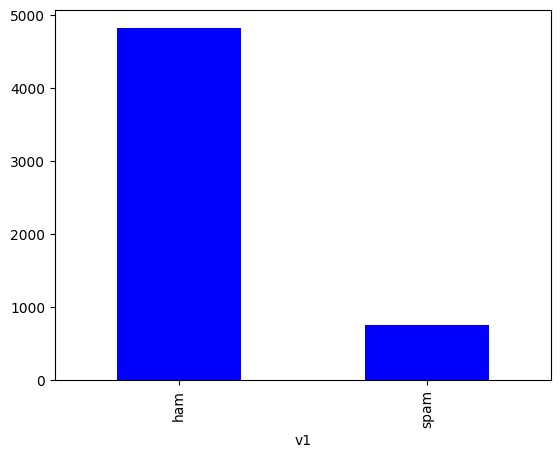

In [18]:
dk["v1"].value_counts().plot(kind="bar", color="blue")
plt.show()
plt.close()

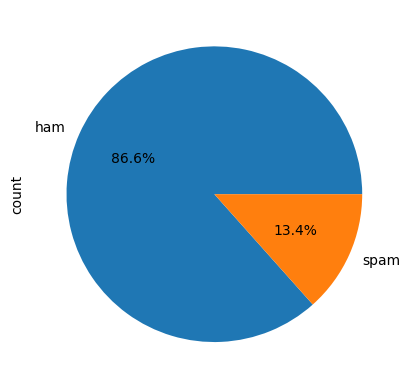

In [70]:
dk["v1"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.show()
plt.close()

here we see that
Dataset is heavily skewed towards Ham
Almost 9 out of 10 messages are legitimate
Only 1 in 7 messages is spam



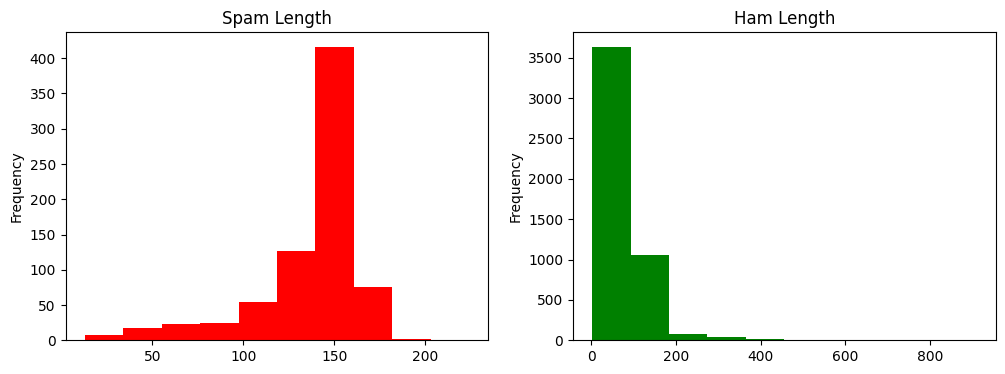

In [72]:
dk["length"] = dk["v2"].apply(len)
dk["word_count"] = dk["v2"].apply(lambda x: len(x.split()))

# Compare length between spam and ham
dk.groupby("v1")[["length", "word_count"]].mean()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dk[df["v1"]=="spam"]["length"].plot(kind="hist", ax=axes[0], color="red", title="Spam Length")
dk[df["v1"]=="ham"]["length"].plot(kind="hist", ax=axes[1], color="green", title="Ham Length")
plt.show()
plt.close()

Most spam is 100-175 characters long
Peak at around 140-150 characters
Very consistent length — spammers use a template!
Rarely short — they need space to include their scam message and Most ham is very short (0-50 characters)
Quick casual messages like "Ok", "Coming now", "See you later"
Few long ham messages — rare but can go up to 800+ characters
Natural human variation in length





/tmp/ipykernel_201/3986979151.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="Reds_r")


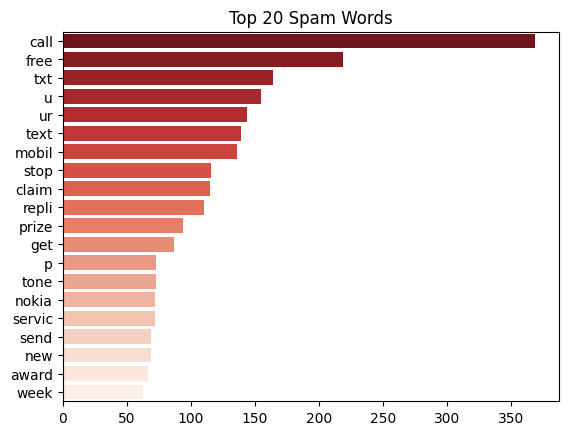

In [73]:
from collections import Counter

spam_tokens = " ".join(df[df["v1"]=="spam"]["cleaned"]).split()
top_spam = Counter(spam_tokens).most_common(20)

words, counts = zip(*top_spam)
sns.barplot(x=list(counts), y=list(words), palette="Reds_r")
plt.title("Top 20 Spam Words")
plt.show()
plt.close()

The printed left are text that appear more in spam message

In [24]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [27]:
stop=stopwords

In [30]:
stop_words = set(stop.words('english'))

In [36]:
stemmer=PorterStemmer()

In [38]:
import nltk
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]  # stemming
    return " ".join(tokens)

dk["cleaned"] = dk["v2"].apply(clean_text)

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(dk["cleaned"])
y = dk["v1"]

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [44]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=40,          # limit tree depth
    min_samples_split=2,   # need 5 samples to split
    min_samples_leaf=1,    # need 2 samples at leaf
    max_features="sqrt",# number of trees
    random_state=42,
    class_weight="balanced"  # handles class imbalance
)

rf_model.fit(X_resampled, y_resampled)



RandomForestClassifier(class_weight='balanced', max_depth=40, random_state=42)

Accuracy: 0.9721973094170404

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       965
        spam       0.91      0.88      0.89       150

    accuracy                           0.97      1115
   macro avg       0.95      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115



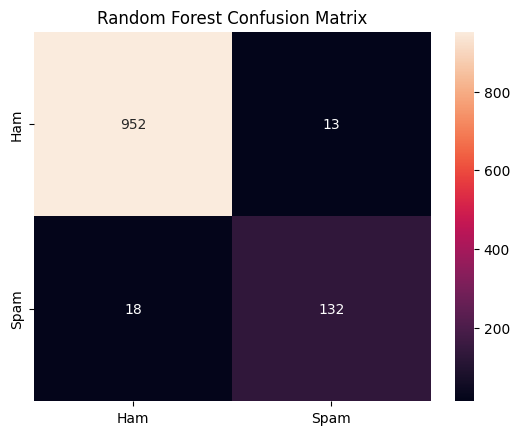

In [65]:
# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt="d",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.title("Random Forest Confusion Matrix")
plt.show()
plt.close()

In [47]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# XGBoost needs numeric labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_resampled)
y_test_encoded = le.transform(y_test)

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=len(y_resampled[y_resampled=="ham"]) / len(y_resampled[y_resampled=="spam"]),  # handles imbalance
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb_model.fit(X_resampled, y_train_encoded)

#

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:39:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

Accuracy: 0.9497757847533632

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      0.96      0.97       965
        spam       0.78      0.88      0.82       150

    accuracy                           0.95      1115
   macro avg       0.88      0.92      0.90      1115
weighted avg       0.95      0.95      0.95      1115



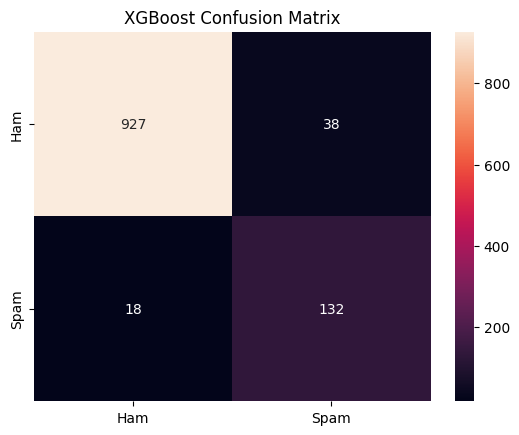

In [49]:
#Predict
y_pred_xgb = xgb_model.predict(X_test)

# Decode back to labels
y_pred_labels = le.inverse_transform(y_pred_xgb)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_labels))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_labels))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_labels),
            annot=True, fmt="d",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.title("XGBoost Confusion Matrix")
plt.show()
plt.close()

In [50]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_resampled, y_resampled)

MultinomialNB()

Accuracy: 0.9282511210762332

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.93      0.96       965
        spam       0.67      0.93      0.78       150

    accuracy                           0.93      1115
   macro avg       0.83      0.93      0.87      1115
weighted avg       0.94      0.93      0.93      1115



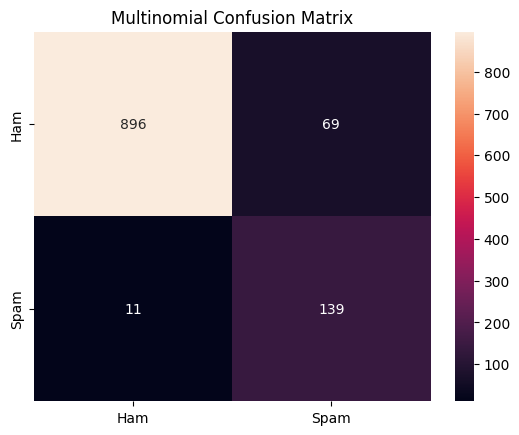

In [51]:
# Predict
y_pred_m = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_m))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_m))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_m),
            annot=True, fmt="d",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.title("Multinomial Confusion Matrix")
plt.show()
plt.close()

In [66]:
from sklearn.model_selection import cross_val_score

# Training accuracy
y_train_pred = rf_model.predict(X_resampled)
train_accuracy = accuracy_score(y_resampled, y_train_pred)

# Test accuracy
y_test_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Cross validation (5 fold)
cv_scores = cross_val_score(rf_model, X_resampled, y_resampled, cv=5, scoring="f1_weighted")

print(f"Train Accuracy     : {train_accuracy:.4f}")
print(f"Test Accuracy      : {test_accuracy:.4f}")
print(f"CV Scores          : {cv_scores}")
print(f"CV Mean            : {cv_scores.mean():.4f}")
print(f"CV Std             : {cv_scores.std():.4f}")

# Check for overfitting
gap = train_accuracy - test_accuracy
print(f"\nTrain-Test Gap     : {gap:.4f}")

if gap < 0.02:
    print("✅ No overfitting — model generalizes well!")
elif gap < 0.05:
    print("⚠️ Slight overfitting — acceptable")
else:
    print("❌ Overfitting detected — model memorized training data!")

Train Accuracy     : 0.9665
Test Accuracy      : 0.9722
CV Scores          : [0.94130955 0.94130955 0.94553806 0.9161242  0.92417699]
CV Mean            : 0.9337
CV Std             : 0.0115

Train-Test Gap     : -0.0057
✅ No overfitting — model generalizes well!


In [68]:
import pickle

# Save model
with open("spam_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Save TF-IDF vectorizer too!
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Model saved! ✅")

Model saved! ✅


In [69]:
import pickle

# Load model and vectorizer
with open("spam_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

with open("tfidf_vectorizer.pkl", "rb") as f:
    tfidf = pickle.load(f)

# Test function
def predict_spam(message):
    cleaned = clean_text(message)
    vectorized = tfidf.transform([cleaned])
    result = rf_model.predict(vectorized)
    proba = rf_model.predict_proba(vectorized)
    confidence = round(max(proba[0]) * 100, 2)
    return f"{'SPAM 🚨' if result[0] == 'spam' else 'HAM ✅'} — Confidence: {confidence}%"

# Try it!
print(predict_spam("Congratulations! You won a free iPhone click here now!"))
print(predict_spam("Hey, are we still meeting tomorrow?"))
print(predict_spam("WINNER! Claim your $1000 prize now! Call 0800"))
print(predict_spam("Can you send me the notes from class?"))

SPAM 🚨 — Confidence: 50.63%
HAM ✅ — Confidence: 91.55%
SPAM 🚨 — Confidence: 83.29%
HAM ✅ — Confidence: 85.84%
